# GLP-1 Access Disparity Analysis
## Who is NOT getting GLP-1 medications despite needing them?

**What this notebook does:**  
We combine 4 free government datasets to find states where obesity is high but GLP-1 drug use is low.  
We then check if race and income explain that gap.

**Data Sources:**
- CMS Medicare Part D 2024 — how many people got GLP-1 drugs per state
- CDC PLACES 2025 — obesity and diabetes rates per state
- Census ACS 2024 — income and race per state
- CDC SVI 2022 — social vulnerability per state

**Research Question:**  
Do states with more Black/Hispanic residents and lower incomes have worse access to GLP-1 medications?

## Step 1 — Import Libraries
These are the tools we need. Run this first.

In [1]:
# If you get an error, run this first:
# !pip install pandas numpy matplotlib seaborn scipy statsmodels

import pandas as pd           # for loading and working with data tables
import numpy as np            # for math operations
import matplotlib.pyplot as plt  # for making charts
import seaborn as sns         # for nicer charts
from scipy import stats       # for correlation tests
import statsmodels.api as sm  # for regression
import warnings
warnings.filterwarnings('ignore')



## Step 2 — Load CMS Drug Data
This file tells us how many Medicare patients received GLP-1 drugs in each state in 2024.  
GLP-1 drugs: Ozempic, Wegovy (semaglutide), Mounjaro, Zepbound (tirzepatide), Victoza (liraglutide), Trulicity (dulaglutide).

In [2]:
cms = pd.read_csv("/content/medicare part 2 by geography.csv", low_memory=False)
print('Total rows in CMS file:', cms.shape[0])
print('Geography types:', cms['Prscrbr_Geo_Lvl'].unique())

Total rows in CMS file: 117661
Geography types: ['National' 'State']


In [3]:
# GLP-1 drug generic names
glp1_names = ['semaglutide', 'tirzepatide', 'liraglutide', 'dulaglutide']

# Keep only: state-level rows AND GLP-1 drugs
cms_glp1 = cms[
    (cms['Prscrbr_Geo_Lvl'] == 'State') &
    (cms['Gnrc_Name'].str.lower().isin(glp1_names))
].copy()

print(f'GLP-1 rows at state level: {cms_glp1.shape[0]}')
print(f'Number of states: {cms_glp1["Prscrbr_Geo_Desc"].nunique()}')

GLP-1 rows at state level: 455
Number of states: 59


In [11]:
# Add up all GLP-1 drugs per state
cms_by_state = cms_glp1.groupby('Prscrbr_Geo_Desc').agg(
    total_patients=('Tot_Benes', 'sum'),   # patients who got GLP-1
    total_claims=('Tot_Clms', 'sum'),       # total prescriptions
    total_cost=('Tot_Drug_Cst', 'sum')      # total drug cost
).reset_index()

cms_by_state = cms_by_state.rename(columns={'Prscrbr_Geo_Desc': 'state_name'})
print(f'States: {cms_by_state.shape[0]}')
cms_by_state.head()

States: 59


,state_name,total_patients,total_claims,total_cost
0,Alabama,96090.0,511857,6.254315e+08
1,Alaska,6718.0,33639,4.404708e+07
2,Arizona,78399.0,362983,4.851619e+08
3,Arkansas,45394.0,251742,2.887076e+08
4,Armed Forces Europe,53.0,210,2.400089e+05


## Step 3 — Load Obesity & Diabetes Data (CDC PLACES)
What % of adults in each state are obese or have diabetes?  
PLACES is county-level — we average up to state level.

In [4]:
places = pd.read_csv(
    '/content/PLACES__Local_Data_for_Better_Health__County_Data__2025_release.csv',
    low_memory=False
)
print('PLACES shape:', places.shape)

# Filter for obesity and diabetes only
places_filtered = places[
    places['MeasureId'].isin(['OBESITY', 'DIABETES']) &
    (places['Data_Value_Type'] == 'Crude prevalence')
][['StateDesc', 'MeasureId', 'Data_Value']].copy()

# Average counties up to state level
places_state = places_filtered.groupby(['StateDesc','MeasureId'])['Data_Value'].mean().reset_index()

# Reshape: one row per state, columns for obesity and diabetes
places_wide = places_state.pivot(index='StateDesc', columns='MeasureId', values='Data_Value').reset_index()
places_wide.columns = ['state_name', 'diabetes_pct', 'obesity_pct']

print(f'States in PLACES: {places_wide.shape[0]}')
places_wide.head()

PLACES shape: (229298, 22)
States in PLACES: 50


,state_name,diabetes_pct,obesity_pct
0,Alabama,16.802985,41.726866
1,Alaska,11.570000,35.730000
2,Arizona,13.393333,32.873333
3,Arkansas,15.293333,40.926667
4,California,12.062069,29.765517


In [5]:
raw_states = set(places_filtered['StateDesc'])
missing = {'Vermont','Wyoming','West Virginia','Wisconsin','Kentucky','Washington','Pennsylvania'}
print(missing - raw_states)          # states missing even from raw filtered data
print(missing & raw_states)          # states present raw but lost in pivot

for s in missing & raw_states:
    print(s, places_filtered[places_filtered['StateDesc']==s]['MeasureId'].unique())

{'Kentucky', 'Pennsylvania'}
{'West Virginia', 'Wisconsin', 'Wyoming', 'Washington', 'Vermont'}
West Virginia ['OBESITY' 'DIABETES']
Wisconsin ['DIABETES' 'OBESITY']
Wyoming ['OBESITY' 'DIABETES']
Washington ['OBESITY' 'DIABETES']
Vermont ['OBESITY' 'DIABETES']


In [6]:
raw_variants = places[places['StateDesc'].str.contains('ashington', case=False, na=False)]['StateDesc'].unique()
print(raw_variants)

['Washington']


In [7]:
print(places_filtered['Data_Value'].dtype)
print(places_filtered[places_filtered['StateDesc']=='Washington'])
print(places_state[places_state['StateDesc']=='Washington'])

float64
         StateDesc MeasureId  Data_Value
198125  Washington   OBESITY        40.2
198198  Washington   OBESITY        35.3
201886  Washington   OBESITY        35.3
202558  Washington   OBESITY        40.5
204746  Washington  DIABETES        11.0
...            ...       ...         ...
226679  Washington  DIABETES        13.3
227265  Washington   OBESITY        31.0
227445  Washington   OBESITY        28.7
228820  Washington   OBESITY        34.3
229146  Washington   OBESITY        26.5

[78 rows x 3 columns]
     StateDesc MeasureId  Data_Value
92  Washington  DIABETES   11.415385
93  Washington   OBESITY   33.943590


## Step 4 — Load Demographics (Census ACS)
Income and racial breakdown per state.

In [8]:
acs = pd.read_csv('/content/acs_demographics_2024.csv')

# Extract state from county name: 'Autauga County, Alabama' -> 'Alabama'
acs['state_name'] = acs['county_name'].str.split(',').str[-1].str.strip()

# Aggregate counties to state level
acs_by_state = acs.groupby('state_name').agg(
    median_income=('median_household_income', 'median'),
    total_pop=('total_population', 'sum'),
    black_pop=('black_population', 'sum'),
    hispanic_pop=('hispanic_population', 'sum'),
    asian_pop=('asian_population', 'sum')
).reset_index()

# Calculate race as % of total population
acs_by_state['pct_black']    = (acs_by_state['black_pop']    / acs_by_state['total_pop'] * 100).round(1)
acs_by_state['pct_hispanic'] = (acs_by_state['hispanic_pop'] / acs_by_state['total_pop'] * 100).round(1)
acs_by_state['pct_asian']    = (acs_by_state['asian_pop']    / acs_by_state['total_pop'] * 100).round(1)

print(f'States in ACS: {acs_by_state.shape[0]}')
acs_by_state[['state_name','median_income','pct_black','pct_hispanic']].head()

States in ACS: 52


,state_name,median_income,pct_black,pct_hispanic
0,Alabama,54563.0,25.8,5.6
1,Alaska,80958.5,3.0,7.3
2,Arizona,62876.0,4.6,31.4
3,Arkansas,51646.0,14.7,9.0
4,California,83473.0,5.4,40.2


## Step 5 — Load Social Vulnerability Index (SVI)
SVI score 0-1. Higher = more vulnerable.  
Combines poverty, unemployment, minority status, language barriers.

In [9]:
svi = pd.read_csv('/content/SVI_2022_US_county.csv')

svi_by_state = svi.groupby('STATE').agg(
    svi_overall=('RPL_THEMES', 'mean'),   # 0-1 overall vulnerability
    svi_poverty=('RPL_THEME1', 'mean'),   # poverty/unemployment
    svi_minority=('RPL_THEME3', 'mean'),  # minority/language
    pct_uninsured=('EP_UNINSUR', 'mean')  # % no health insurance
).reset_index()

svi_by_state.columns = ['state_name','svi_overall','svi_poverty','svi_minority','pct_uninsured']

print(f'States in SVI: {svi_by_state.shape[0]}')
svi_by_state.head()

States in SVI: 51


,state_name,svi_overall,svi_poverty,svi_minority,pct_uninsured
0,Alabama,0.671582,0.693924,0.674607,9.804478
1,Alaska,0.604770,0.478500,0.832597,15.680000
2,Arizona,0.829213,0.749767,0.839607,11.333333
3,Arkansas,0.690255,0.673488,0.560131,8.330667
4,California,0.690778,0.631514,0.802922,6.887931


In [12]:
cms_states = set(cms_by_state['state_name'])
places_states = set(places_wide['state_name'])
missing = cms_states - places_states
for s in missing:
    print(repr(s))  # repr() exposes whitespace/hidden chars
# also check if a close match exists on the PLACES side
for s in missing:
    matches = [p for p in places_states if s.strip().lower() in p.strip().lower()]
    print(s, '->', matches)

'Unknown'
'Kentucky'
'Northern Mariana Islands'
'Pennsylvania'
'Foreign Country'
'Virgin Islands'
'Armed Forces Europe'
'Armed Forces Pacific'
'Puerto Rico'
'Guam'
Unknown -> []
Kentucky -> []
Northern Mariana Islands -> []
Pennsylvania -> []
Foreign Country -> []
Virgin Islands -> []
Armed Forces Europe -> []
Armed Forces Pacific -> []
Puerto Rico -> []
Guam -> []


## Step 6 — Merge All 4 Datasets
Join everything on state_name. Each row = one state with all variables.

In [13]:
# Start with CMS, add each dataset one at a time
df = cms_by_state.merge(places_wide, on='state_name', how='inner')
print(f'CMS + PLACES: {df.shape[0]} states')

df = df.merge(
    acs_by_state[['state_name','median_income','total_pop',
                  'pct_black','pct_hispanic','pct_asian']],
    on='state_name', how='left'
)
print(f'+ ACS: {df.shape[0]} states')

df = df.merge(svi_by_state, on='state_name', how='left')
print(f'+ SVI: {df.shape[0]} states')

# Check what dropped out
dropped = set(cms_by_state['state_name']) - set(places_wide['state_name'])
print(f'\nStates dropped (territories not in PLACES): {dropped}')

CMS + PLACES: 49 states
+ ACS: 49 states
+ SVI: 49 states

States dropped (territories not in PLACES): {'Unknown', 'Kentucky', 'Northern Mariana Islands', 'Pennsylvania', 'Foreign Country', 'Virgin Islands', 'Armed Forces Europe', 'Armed Forces Pacific', 'Puerto Rico', 'Guam'}


## Step 7 — Calculate Access Gap Score
The core metric.

Gap Score = (obesity burden / national avg) - (GLP-1 use / national avg)

- Positive gap = high obesity, low GLP-1 = under-served
- Negative gap = GLP-1 use matches obesity burden = well-served

In [14]:
# GLP-1 users per 1,000 people (makes states comparable)
df['glp1_per_1000'] = (df['total_patients'] / df['total_pop'] * 1000).round(2)

# FIX: blended demand baseline (obesity + diabetes) instead of obesity alone.
# GLP-1s are indicated for both diabetes and obesity, and prescriber data
# doesn't separate by indication, so a demand baseline using obesity alone
# understates true clinical need in high-diabetes/lower-obesity states.
from scipy.stats import zscore
df['obesity_z']  = zscore(df['obesity_pct'], nan_policy='omit')
df['diabetes_z'] = zscore(df['diabetes_pct'], nan_policy='omit')
df['demand_z']   = 0.5 * df['obesity_z'] + 0.5 * df['diabetes_z']
df['glp1_z']     = zscore(df['glp1_per_1000'], nan_policy='omit')

# Gap score (z-score based, so no single variable dominates by variance)
df['gap_score'] = (df['demand_z'] - df['glp1_z']).round(3)

df = df.sort_values('gap_score', ascending=False).reset_index(drop=True)

print('TOP 10 UNDER-SERVED (high obesity+diabetes demand, low GLP-1):')
print(df[['state_name','obesity_pct','diabetes_pct','glp1_per_1000','gap_score']].head(10).to_string())
print('\nTOP 10 WELL-SERVED:')
print(df[['state_name','obesity_pct','diabetes_pct','glp1_per_1000','gap_score']].tail(10).to_string())


TOP 10 UNDER-SERVED (high obesity+diabetes demand, low GLP-1):
     state_name  obesity_pct  diabetes_pct  glp1_per_1000  gap_score
0      Virginia    37.620301     14.262406          10.32      1.323
1        Oregon    35.308333     12.925000           9.48      1.010
2  South Dakota    36.803030     13.524242          10.79      0.895
3      Maryland    36.320833     12.754167          10.08      0.888
4      Nebraska    39.364516     12.472043          11.02      0.862
5       Wyoming    34.069565     11.665217           8.62      0.848
6        Alaska    35.730000     11.570000           9.13      0.848
7    New Mexico    34.769697     15.024242          11.53      0.776
8         Texas    37.423320     14.618972          12.22      0.758
9    Washington    33.943590     11.415385           8.68      0.753

TOP 10 WELL-SERVED:
              state_name  obesity_pct  diabetes_pct  glp1_per_1000  gap_score
39             Louisiana    42.103125     16.501562          19.67     -0.710
4

## Step 8 — Statistical Analysis
Does race or income predict the access gap?

Pearson correlation: measures how strongly two variables move together  
r close to +1 = strong positive  r close to -1 = strong negative  
p < 0.05 = statistically significant

In [15]:
variables = {
    '% Black population':      'pct_black',
    '% Hispanic population':   'pct_hispanic',
    '% Asian population':      'pct_asian',
    'Median household income': 'median_income',
    'SVI vulnerability score': 'svi_overall',
    '% Uninsured':             'pct_uninsured',
    'Obesity prevalence':      'obesity_pct',
    'Diabetes prevalence':     'diabetes_pct'
}

print('NOTE: obesity/diabetes prevalence are components of gap_score\'s\n'
      '      construction (demand_z) — their correlation here is partly\n'
      '      mechanical, not evidence of an independent effect.')
print(f'{"Variable":<30} {"r":>8} {"p-value":>10} {"Significant?":>12}')


corr_results = []
for label, col in variables.items():
    clean = df[['gap_score', col]].dropna()
    r, p  = stats.pearsonr(clean['gap_score'], clean[col])
    sig   = 'YES ***' if p < 0.05 else 'no'
    print(f'{label:<30} {r:>8.3f} {p:>10.4f} {sig:>12}')
    corr_results.append({'variable': label, 'r': round(r,3), 'p_value': round(p,4)})

NOTE: obesity/diabetes prevalence are components of gap_score's
      construction (demand_z) — their correlation here is partly
      mechanical, not evidence of an independent effect.
Variable                              r    p-value Significant?
% Black population               -0.141     0.3345           no
% Hispanic population             0.193     0.1845           no
% Asian population                0.058     0.6911           no
Median household income          -0.346     0.0148      YES ***
SVI vulnerability score           0.068     0.6404           no
% Uninsured                       0.445     0.0014      YES ***
Obesity prevalence                0.370     0.0088      YES ***
Diabetes prevalence               0.324     0.0232      YES ***


In [16]:
# Multiple regression: which variables predict gap score
# while controlling for all others?
# FIX: obesity_pct removed from predictors — it's a direct component of
# gap_score's construction (via demand_z), so including it as a predictor
# is circular. diabetes_pct excluded for the same reason.

reg_vars = ['pct_black', 'pct_hispanic', 'median_income', 'svi_overall', 'pct_uninsured']
reg_data = df[['gap_score'] + reg_vars].dropna()

X = sm.add_constant(reg_data[reg_vars])  # add intercept
y = reg_data['gap_score']

model = sm.OLS(y, X).fit()

print('REGRESSION RESULTS')

print(f'R-squared = {model.rsquared:.3f}  '
      f'(explains {model.rsquared*100:.1f}% of gap variation)')
print(f'Overall p-value = {model.f_pvalue:.4f}')
print()
print(f'{"Variable":<25} {"Coefficient":>12} {"p-value":>10} {"Significant?":>12}')

for var in reg_vars:
    coef = model.params[var]
    pval = model.pvalues[var]
    sig  = 'YES ***' if pval < 0.05 else ('marginal' if pval < 0.10 else 'no')
    print(f'{var:<25} {coef:>12.4f} {pval:>10.4f} {sig:>12}')
print()
print('Positive coef = increases gap (worse access)')
print('Negative coef = decreases gap (better access)')

# VIF check — flags multicollinearity so we don't over-interpret which
# single predictor "wins" when predictors are correlated with each other
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print('\nVIF (>5 suggests problematic multicollinearity):')
print(vif.to_string(index=False))


REGRESSION RESULTS
R-squared = 0.314  (explains 31.4% of gap variation)
Overall p-value = 0.0051

Variable                   Coefficient    p-value Significant?
pct_black                       0.0053     0.7103           no
pct_hispanic                    0.0276     0.0501     marginal
median_income                  -0.0000     0.0959     marginal
svi_overall                    -1.8107     0.0747     marginal
pct_uninsured                   0.1074     0.0137      YES ***

Positive coef = increases gap (worse access)
Negative coef = decreases gap (better access)

VIF (>5 suggests problematic multicollinearity):
     variable       VIF
        const 81.513675
    pct_black  1.897133
 pct_hispanic  1.774621
median_income  1.606565
  svi_overall  3.034048
pct_uninsured  1.734205


## Step 9 — Visualizations

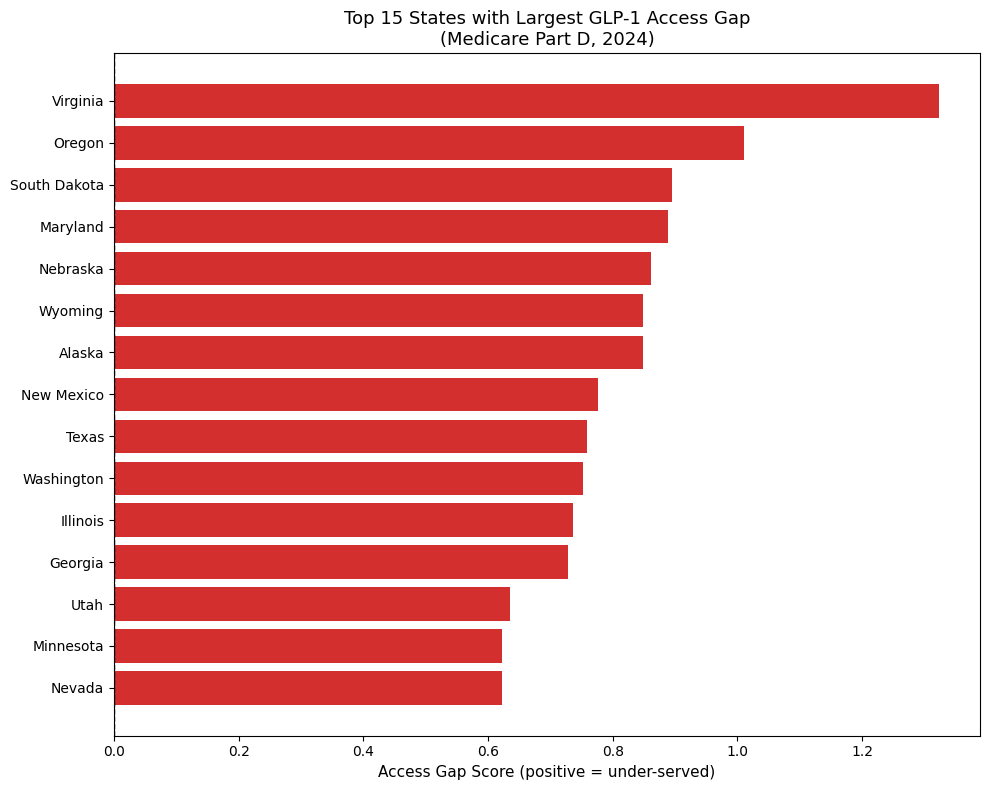

In [17]:
# Chart 1: Top under-served states
fig, ax = plt.subplots(figsize=(10, 8))
top15  = df.nlargest(15, 'gap_score')
colors = ['#d32f2f' if x > 0 else '#388e3c' for x in top15['gap_score']]
ax.barh(top15['state_name'], top15['gap_score'], color=colors)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Access Gap Score (positive = under-served)', fontsize=11)
ax.set_title('Top 15 States with Largest GLP-1 Access Gap\n(Medicare Part D, 2024)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('chart1_gap_states.png', dpi=150)
plt.show()

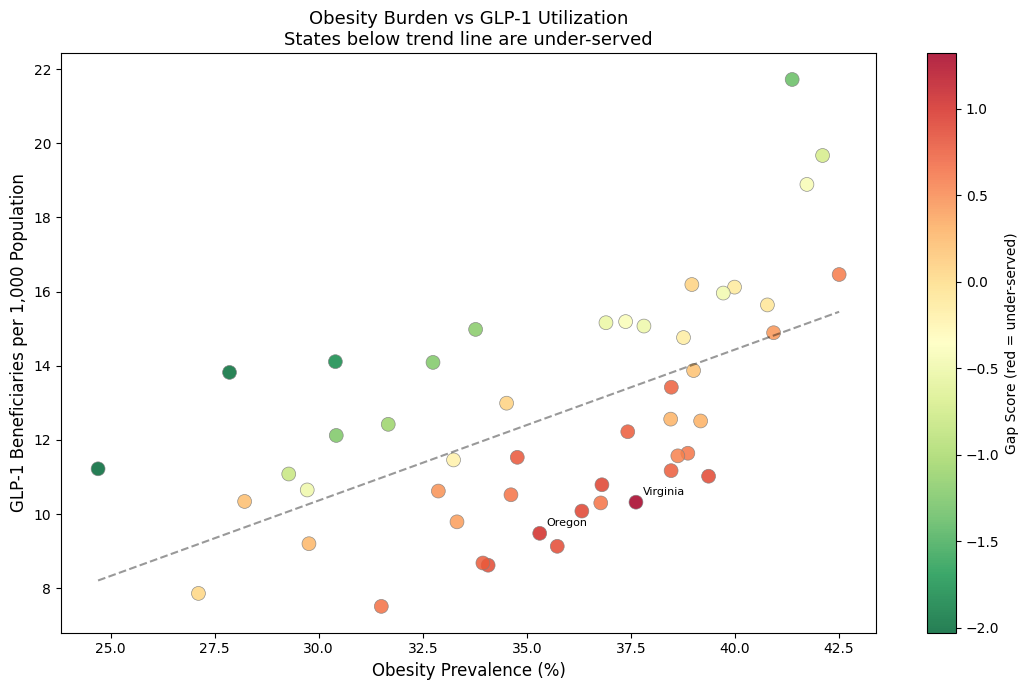

In [18]:
# Chart 2: Obesity burden vs GLP-1 use scatter
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(df['obesity_pct'], df['glp1_per_1000'],
                     c=df['gap_score'], cmap='RdYlGn_r',
                     s=100, alpha=0.85, edgecolors='gray', linewidths=0.5)
plt.colorbar(scatter, label='Gap Score (red = under-served)')
# Trend line
# FIX: dropna() must be applied to both columns together, not independently,
# or NaNs in different rows leave mismatched/misaligned x and y arrays.
trend_clean = df[['obesity_pct', 'glp1_per_1000']].dropna()
z = np.polyfit(trend_clean['obesity_pct'], trend_clean['glp1_per_1000'], 1)
p_line = np.poly1d(z)
x_vals = np.linspace(trend_clean['obesity_pct'].min(), trend_clean['obesity_pct'].max(), 100)
ax.plot(x_vals, p_line(x_vals), 'k--', alpha=0.4, linewidth=1.5)
# Label outliers
# NOTE: threshold updated for z-score gap_score scale (was 0.22 under old mean-ratio scale)
for _, row in df[df['gap_score'] > 1.0].iterrows():
    ax.annotate(row['state_name'], (row['obesity_pct'], row['glp1_per_1000']),
                xytext=(5,5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Obesity Prevalence (%)', fontsize=12)
ax.set_ylabel('GLP-1 Beneficiaries per 1,000 Population', fontsize=12)
ax.set_title('Obesity Burden vs GLP-1 Utilization\nStates below trend line are under-served', fontsize=13)
plt.tight_layout()
plt.savefig('chart2_obesity_vs_glp1.png', dpi=150)
plt.show()

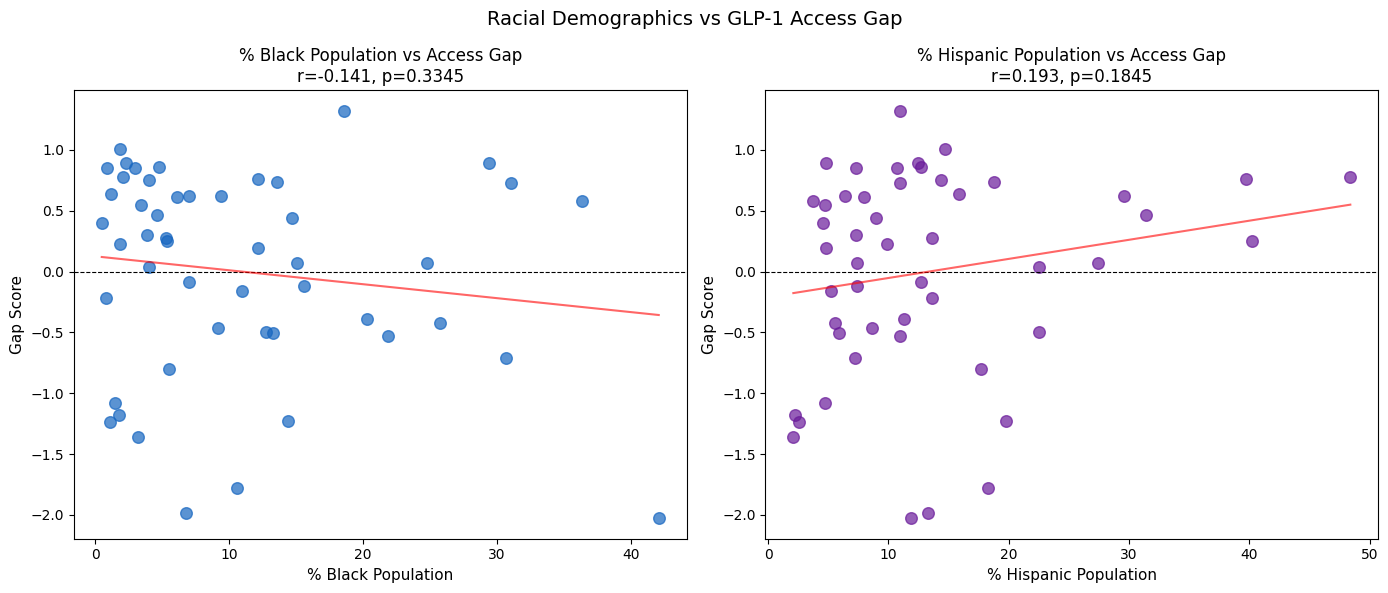

In [19]:
# Chart 3: Race vs gap score
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, color, label in [
    (axes[0], 'pct_black',    '#1565c0', '% Black Population'),
    (axes[1], 'pct_hispanic', '#6a1b9a', '% Hispanic Population')
]:
    clean = df[[col,'gap_score']].dropna()
    r, p  = stats.pearsonr(clean[col], clean['gap_score'])
    ax.scatter(df[col], df['gap_score'], color=color, alpha=0.7, s=70)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    z = np.polyfit(clean[col], clean['gap_score'], 1)
    x_vals = np.linspace(clean[col].min(), clean[col].max(), 100)
    ax.plot(x_vals, np.poly1d(z)(x_vals), 'r-', alpha=0.6)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Gap Score', fontsize=11)
    ax.set_title(f'{label} vs Access Gap\nr={r:.3f}, p={p:.4f}', fontsize=12)
plt.suptitle('Racial Demographics vs GLP-1 Access Gap', fontsize=14)
plt.tight_layout()
plt.savefig('chart3_race_vs_gap.png', dpi=150)
plt.show()

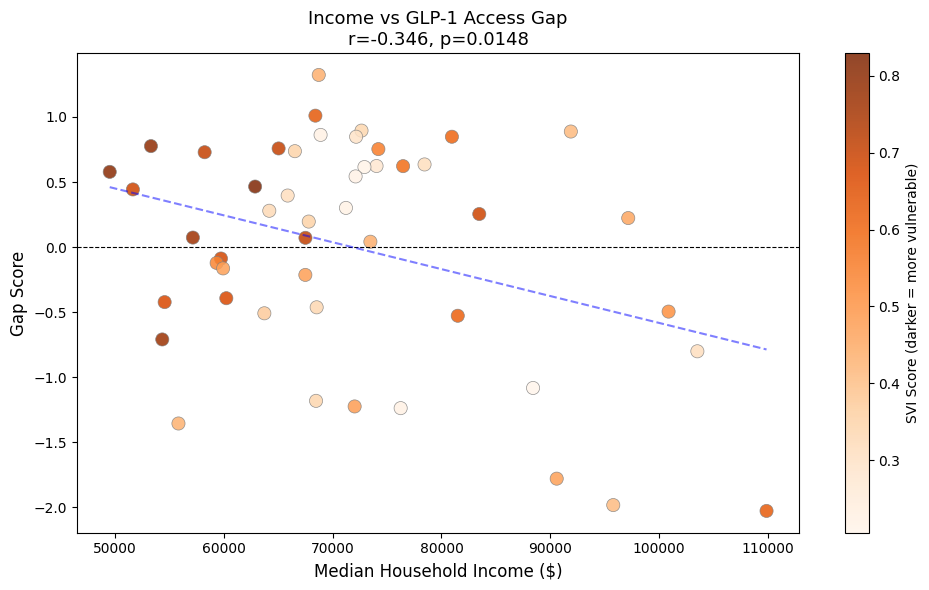

In [20]:
# Chart 4: Income vs gap
fig, ax = plt.subplots(figsize=(10, 6))
clean3 = df[['median_income','gap_score']].dropna()
r3, p3 = stats.pearsonr(clean3['median_income'], clean3['gap_score'])
scatter = ax.scatter(df['median_income'], df['gap_score'],
                     c=df['svi_overall'], cmap='Oranges',
                     s=90, alpha=0.85, edgecolors='gray', linewidths=0.5)
plt.colorbar(scatter, label='SVI Score (darker = more vulnerable)')
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
z3 = np.polyfit(clean3['median_income'], clean3['gap_score'], 1)
x_vals3 = np.linspace(clean3['median_income'].min(), clean3['median_income'].max(), 100)
ax.plot(x_vals3, np.poly1d(z3)(x_vals3), 'b--', alpha=0.5, linewidth=1.5)
ax.set_xlabel('Median Household Income ($)', fontsize=12)
ax.set_ylabel('Gap Score', fontsize=12)
ax.set_title(f'Income vs GLP-1 Access Gap\nr={r3:.3f}, p={p3:.4f}', fontsize=13)
plt.tight_layout()
plt.savefig('chart4_income_vs_gap.png', dpi=150)
plt.show()

## Step 10 — Key Findings & Save

In [21]:

print('KEY FINDINGS')

print(f'States analyzed: {df.shape[0]}')
print(f'Total GLP-1 Medicare patients: {df["total_patients"].sum():,.0f}')
print(f'Total drug spend: ${df["total_cost"].sum()/1e9:.2f} billion')

print('\nTop 5 UNDER-SERVED states:')
for _, row in df.nlargest(5, 'gap_score').iterrows():
    print(f'  {row["state_name"]:<20} obesity={row["obesity_pct"]:.1f}%  '
          f'GLP1/1000={row["glp1_per_1000"]:.1f}  gap={row["gap_score"]:.3f}')

print('\nCorrelations with gap score:')
for label, col in [('% Black','pct_black'),('% Hispanic','pct_hispanic'),
                   ('Median income','median_income')]:
    clean = df[[col,'gap_score']].dropna()
    r, p  = stats.pearsonr(clean[col], clean['gap_score'])
    sig   = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'  {label:<20} r={r:.3f}  p={p:.4f}  ({sig})')

print('\nRegression R-squared:', round(model.rsquared, 3))

print('\nLIMITATIONS:')
print('  - Medicare Part D only (65+ population, not all ages)')
print('  - State-level masks within-state county variation')
print('  - SVI from 2022; other data from 2024-2025')
print('  - Correlation does not imply causation')

# Save final dataset
df.to_csv('glp1_access_disparity_final.csv', index=False)
print(f'\nSaved: {df.shape[0]} states, {df.shape[1]} columns')

KEY FINDINGS
States analyzed: 49
Total GLP-1 Medicare patients: 3,954,762
Total drug spend: $25.37 billion

Top 5 UNDER-SERVED states:
  Virginia             obesity=37.6%  GLP1/1000=10.3  gap=1.323
  Oregon               obesity=35.3%  GLP1/1000=9.5  gap=1.010
  South Dakota         obesity=36.8%  GLP1/1000=10.8  gap=0.895
  Maryland             obesity=36.3%  GLP1/1000=10.1  gap=0.888
  Nebraska             obesity=39.4%  GLP1/1000=11.0  gap=0.862

Correlations with gap score:
  % Black              r=-0.141  p=0.3345  (not significant)
  % Hispanic           r=0.193  p=0.1845  (not significant)
  Median income        r=-0.346  p=0.0148  (SIGNIFICANT)

Regression R-squared: 0.314

LIMITATIONS:
  - Medicare Part D only (65+ population, not all ages)
  - State-level masks within-state county variation
  - SVI from 2022; other data from 2024-2025
  - Correlation does not imply causation

Saved: 49 states, 21 columns


## Step 11 — County-Level Analysis
Same approach as above, but at the county level (2,781 counties) instead of state level.
We join prescriber-level CMS data to counties via NPI → ZIP → FIPS crosswalk, then merge in the same PLACES, ACS, and SVI variables used in the state analysis.


In [22]:
# Step 11 — Build County-Level GLP-1 Data (fixed)

prescribers = pd.read_csv('/content/cms_glp1_prescriber_2024.csv')
nppes_zip   = pd.read_csv('/content/nppes_glp1_zip.csv')
zip_county  = pd.read_csv('/content/zip_to_county_fips_clean.csv')

# Fix ALL zip/FIPS columns to zero-padded strings
nppes_zip['zip']       = nppes_zip['zip'].astype(str).str.zfill(5)
zip_county['zipcode']  = zip_county['zipcode'].astype(str).str.zfill(5)
zip_county['fips']     = zip_county['fips'].astype(str).str.zfill(5)
prescribers['bu'] = prescribers['bu'].astype(str)
nppes_zip['NPI']           = nppes_zip['NPI'].astype(str)

# Verify fix
print('NPPES zip sample:', nppes_zip['zip'].head(3).tolist())
print('Crosswalk zipcode sample:', zip_county['zipcode'].head(3).tolist())
print('Crosswalk fips sample:', zip_county['fips'].head(3).tolist())

# FIX (bug #3): ZIP codes can span multiple counties, so zip_county may have
# more than one row per zipcode. Merging against a non-unique crosswalk fans
# out prescriber rows and double-counts claims/cost across counties.
# Check for duplicates, and if present, keep only the primary county per ZIP
# (the one covering the largest share of that ZIP, if a weight column exists;
# otherwise fall back to the first listed county and flag it).
dupe_zips = zip_county['zipcode'].duplicated().sum()
print(f'\nDuplicate zipcode rows in crosswalk: {dupe_zips}')

if dupe_zips > 0:
    weight_col = next((c for c in ['res_ratio', 'tot_ratio', 'bus_ratio', 'weight']
                        if c in zip_county.columns), None)
    if weight_col:
        print(f'Using "{weight_col}" to keep the primary county per ZIP.')
        zip_county_unique = (
            zip_county.sort_values(weight_col, ascending=False)
                      .drop_duplicates(subset='zipcode', keep='first')
        )
    else:
        print('No weighting column found — keeping first listed county per ZIP '
              'as an approximation. Treat county-level counts as directional, '
              'not exact, for ZIPs that span county lines.')
        zip_county_unique = zip_county.drop_duplicates(subset='zipcode', keep='first')
else:
    zip_county_unique = zip_county

# Join 1: prescriber + zip via NPI
step1 = prescribers.merge(nppes_zip, left_on='bu', right_on='NPI', how='left')
print(f'\nAfter adding zip: {step1.shape[0]} rows')
print(f'NPIs with zip matched: {step1["zip"].notna().sum()}')

# Join 2: add county FIPS via zip (deduped crosswalk avoids row fan-out)
step2 = step1.merge(
    zip_county_unique[['zipcode','county','state_abbr','fips']],
    left_on='zip', right_on='zipcode', how='left'
)
print(f'After adding county FIPS: {step2["fips"].notna().sum()} matched')
print(f'Row count sanity check — step1: {step1.shape[0]}, step2: {step2.shape[0]} '
      f'(should match; a mismatch means the crosswalk merge is still fanning out rows)')

# FIX (bug #2): aggregate total_patients (Tot_Benes) alongside claims, so the
# county-level GLP-1 metric matches the definition used at the state level
# (state uses total_patients/beneficiaries, not claims). Assumes the
# prescriber-level file carries a Tot_Benes column, matching the schema of
# the state-level CMS file used earlier in this notebook.
agg_dict = {
    'total_prescribers': ('bu', 'nunique'),
    'total_claims': ('Tot_Clms', 'sum'),
    'total_cost': ('Tot_Drug_Cst', 'sum'),
}
if 'Tot_Benes' in step2.columns:
   agg_dict['total_patients'] = ('Tot_Benes', lambda x: x.sum(min_count=1))
else:
    print('\nWARNING: "Tot_Benes" column not found in prescriber file — '
          'county-level GLP-1 rate will fall back to claims, which is NOT '
          'directly comparable to the state-level patient-based rate.')

county_cms = step2.groupby(['fips','county','state_abbr']).agg(**agg_dict).reset_index()

print(f'\nCounties with GLP-1 prescribing: {county_cms.shape[0]}')
print(county_cms.head())

NPPES zip sample: ['79415', '11021', '08094']
Crosswalk zipcode sample: ['35004', '35005', '35006']
Crosswalk fips sample: ['01115', '01073', '01073']

Duplicate zipcode rows in crosswalk: 55
No weighting column found — keeping first listed county per ZIP as an approximation. Treat county-level counts as directional, not exact, for ZIPs that span county lines.

After adding zip: 414262 rows
NPIs with zip matched: 414260
After adding county FIPS: 396260 matched
Row count sanity check — step1: 414262, step2: 414262 (should match; a mismatch means the crosswalk merge is still fanning out rows)

Counties with GLP-1 prescribing: 2995
    fips   county state_abbr  total_prescribers  total_claims   total_cost  \
0  01001  Autauga         AL                 27          3809   4749615.80   
1  01003  Baldwin         AL                155         23445  30385041.65   
2  01005  Barbour         AL                 11          1870   2205817.21   
3  01007     Bibb         AL                 38    

In [23]:
# Run this before Step 12 to verify PLACES LocationID format
print('PLACES LocationID sample:', places['LocationID'].head(3).tolist())
print('PLACES LocationID dtype:', places['LocationID'].dtype)

PLACES LocationID sample: [5043, 5049, 5061]
PLACES LocationID dtype: int64


In [24]:
# Step 12 — PLACES at county level (fixed)

places_county = places[
    places['MeasureId'].isin(['OBESITY', 'DIABETES']) &
    (places['Data_Value_Type'] == 'Crude prevalence')
][['LocationID', 'StateDesc', 'LocationName', 'MeasureId', 'Data_Value']].copy()

# Fix: float -> int -> string -> zero pad to 5 digits
places_county['fips'] = places_county['LocationID'].astype('Int64').astype(str).str.zfill(5)

# Pivot to wide format
places_county_wide = places_county.pivot_table(
    index=['fips', 'StateDesc', 'LocationName'],
    columns='MeasureId',
    values='Data_Value'
).reset_index()

places_county_wide.columns = ['fips', 'state_name', 'county_name',
                               'diabetes_pct', 'obesity_pct']

print(f'Counties in PLACES: {places_county_wide.shape[0]}')
print('FIPS sample:', places_county_wide['fips'].head(3).tolist())
print(places_county_wide.head())

Counties in PLACES: 2956
FIPS sample: ['01001', '01003', '01005']
    fips state_name county_name  diabetes_pct  obesity_pct
0  01001    Alabama     Autauga          13.3         39.8
1  01003    Alabama     Baldwin          13.4         35.2
2  01005    Alabama     Barbour          19.6         46.8
3  01007    Alabama        Bibb          16.2         43.9
4  01009    Alabama      Blount          13.8         36.1


In [25]:
# Step 13 — ACS and SVI at county level

acs = pd.read_csv('/content/acs_demographics_2024.csv')
svi = pd.read_csv('/content/SVI_2022_US_county.csv')

# ACS county level
acs_county = acs[['FIPS', 'county_name', 'median_household_income',
                   'total_population', 'pct_black',
                   'pct_hispanic', 'pct_asian']].copy()

acs_county = acs_county.rename(columns={
    'FIPS': 'fips',
    'median_household_income': 'median_income',
    'total_population': 'total_pop'
})

# Fix FIPS
acs_county['fips'] = acs_county['fips'].astype(str).str.zfill(5)

print(f'Counties in ACS: {acs_county.shape[0]}')
print('ACS FIPS sample:', acs_county['fips'].head(3).tolist())

# SVI county level
svi_county = svi[['FIPS', 'COUNTY', 'STATE',
                   'RPL_THEMES', 'RPL_THEME1',
                   'RPL_THEME3', 'EP_UNINSUR']].copy()

svi_county = svi_county.rename(columns={
    'FIPS': 'fips',
    'RPL_THEMES': 'svi_overall',
    'RPL_THEME1': 'svi_poverty',
    'RPL_THEME3': 'svi_minority',
    'EP_UNINSUR': 'pct_uninsured'
})

# Fix FIPS
svi_county['fips'] = svi_county['fips'].astype(str).str.zfill(5)

print(f'Counties in SVI: {svi_county.shape[0]}')
print('SVI FIPS sample:', svi_county['fips'].head(3).tolist())

Counties in ACS: 3222
ACS FIPS sample: ['01001', '01003', '01005']
Counties in SVI: 3144
SVI FIPS sample: ['01001', '01003', '01005']


In [26]:
# Step 14 — Merge all at county level

county_df = county_cms.merge(places_county_wide, on='fips', how='inner')
print(f'CMS + PLACES: {county_df.shape[0]} counties')

county_df = county_df.merge(
    acs_county[['fips','median_income','total_pop',
                'pct_black','pct_hispanic','pct_asian']],
    on='fips', how='left'
)
print(f'+ ACS: {county_df.shape[0]} counties')

county_df = county_df.merge(
    svi_county[['fips','svi_overall','svi_poverty',
                'svi_minority','pct_uninsured']],
    on='fips', how='left'
)
print(f'+ SVI: {county_df.shape[0]} counties')

# GLP-1 per 1,000 population
# FIX (bug #2): use total_patients (beneficiaries), matching the metric used
# in the state-level analysis, so state and county gap scores mean the same
# thing. Falls back to claims only if patient counts weren't available.
if 'total_patients' in county_df.columns:
    county_df['glp1_per_1000'] = (
        county_df['total_patients'] / county_df['total_pop'] * 1000
    ).round(2)
else:
    print('WARNING: no total_patients column — using claims as a proxy. '
          'This is NOT directly comparable to the state-level patient rate.')
    county_df['glp1_per_1000'] = (
        county_df['total_claims'] / county_df['total_pop'] * 1000
    ).round(2)

# FIX: blended demand baseline (obesity + diabetes), z-score normalized.
# Same rationale as state level — GLP-1s serve both indications, and
# z-scores prevent whichever variable has larger variance from dominating.
from scipy.stats import zscore
county_df['obesity_z']  = zscore(county_df['obesity_pct'], nan_policy='omit')
county_df['diabetes_z'] = zscore(county_df['diabetes_pct'], nan_policy='omit')
county_df['demand_z']   = 0.5 * county_df['obesity_z'] + 0.5 * county_df['diabetes_z']
county_df['glp1_z']     = zscore(county_df['glp1_per_1000'], nan_policy='omit')

county_df['gap_score'] = (county_df['demand_z'] - county_df['glp1_z']).round(3)

county_df = county_df.sort_values('gap_score', ascending=False).reset_index(drop=True)

print(f'\nFinal county dataset: {county_df.shape[0]} counties')
print('\nTop 10 most under-served counties:')
print(county_df[['county_name','state_name','obesity_pct',
                  'glp1_per_1000','gap_score']].head(10).to_string())

CMS + PLACES: 2781 counties
+ ACS: 2781 counties
+ SVI: 2781 counties

Final county dataset: 2781 counties

Top 10 most under-served counties:
       county_name      state_name  obesity_pct  glp1_per_1000  gap_score
0           Greene         Alabama         52.7           2.96      4.833
1          Bullock         Alabama         51.3           4.08      4.058
2        Humphreys     Mississippi         52.4           5.81      3.932
3            Perry         Alabama         52.9           9.09      3.471
4             Todd    South Dakota         49.3           2.60      3.356
5  Jefferson Davis     Mississippi         45.4           1.62      3.294
6            Yazoo     Mississippi         50.5           2.78      3.052
7             Clay     Mississippi         47.6           1.80      3.004
8           Holmes     Mississippi         50.7           9.33      2.965
9     Williamsburg  South Carolina         45.0           2.25      2.901


In [27]:
# Step 15 — County-level statistics and save

from scipy import stats

print('COUNTY-LEVEL CORRELATIONS WITH GAP SCORE')

print('NOTE: obesity/diabetes prevalence are components of gap_score\'s\n'
      '      construction (demand_z) — their correlation here is partly\n'
      '      mechanical, not evidence of an independent effect.')
print(f'{"Variable":<25} {"r":>8} {"p-value":>10} {"Significant?":>12}')


variables = {
    '% Black':        'pct_black',
    '% Hispanic':     'pct_hispanic',
    '% Asian':        'pct_asian',
    'Median income':  'median_income',
    'SVI overall':    'svi_overall',
    '% Uninsured':    'pct_uninsured',
    'Obesity %':      'obesity_pct',
    'Diabetes %':     'diabetes_pct'
}

for label, col in variables.items():
    clean = county_df[[col, 'gap_score']].dropna()
    r, p  = stats.pearsonr(clean[col], clean['gap_score'])
    sig   = 'YES ***' if p < 0.05 else 'no'
    print(f'{label:<25} {r:>8.3f} {p:>10.4f} {sig:>12}')


COUNTY-LEVEL CORRELATIONS WITH GAP SCORE
NOTE: obesity/diabetes prevalence are components of gap_score's
      construction (demand_z) — their correlation here is partly
      mechanical, not evidence of an independent effect.
Variable                         r    p-value Significant?
% Black                      0.191     0.0000      YES ***
% Hispanic                  -0.043     0.0317      YES ***
% Asian                     -0.282     0.0000      YES ***
Median income               -0.354     0.0000      YES ***
SVI overall                  0.138     0.0000      YES ***
% Uninsured                  0.165     0.0000      YES ***
Obesity %                    0.548     0.0000      YES ***
Diabetes %                   0.490     0.0000      YES ***


In [28]:
# County-level regression
# FIX: obesity_pct removed — it's baked into gap_score's construction via
# demand_z, so including it as a predictor is circular. Same for diabetes_pct.
import statsmodels.api as sm

reg_vars = ['pct_black', 'pct_hispanic', 'median_income',
            'svi_overall', 'pct_uninsured']

reg_data = county_df[['gap_score'] + reg_vars].dropna()
print(f'Counties in regression: {len(reg_data)}')

X = sm.add_constant(reg_data[reg_vars])
y = reg_data['gap_score']

model_county = sm.OLS(y, X).fit()

print(f'\nR-squared: {model_county.rsquared:.3f}')
print(f'Overall p-value: {model_county.f_pvalue:.6f}')
print()
print(f'{"Variable":<25} {"Coefficient":>12} {"p-value":>10} {"Significant?":>12}')

for var in reg_vars:
    coef = model_county.params[var]
    pval = model_county.pvalues[var]
    sig  = 'YES ***' if pval < 0.05 else ('marginal' if pval < 0.10 else 'no')
    print(f'{var:<25} {coef:>12.4f} {pval:>10.4f} {sig:>12}')

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print('\nVIF (>5 suggests problematic multicollinearity):')
print(vif.to_string(index=False))


Counties in regression: 2453

R-squared: 0.165
Overall p-value: 0.000000

Variable                   Coefficient    p-value Significant?
pct_black                       0.0173     0.0000      YES ***
pct_hispanic                    0.0079     0.0001      YES ***
median_income                  -0.0000     0.0000      YES ***
svi_overall                    -1.2269     0.0000      YES ***
pct_uninsured                   0.0283     0.0000      YES ***

VIF (>5 suggests problematic multicollinearity):
     variable       VIF
        const 49.164612
    pct_black  1.556347
 pct_hispanic  1.718946
median_income  1.770603
  svi_overall  3.042479
pct_uninsured  1.633016


## Step 15b — County-Level Visualizations

Figures 2 and 6 in the preprint. Both read from `county_df` and `model_county`
built above, so they stay in sync with whatever the regression actually produced.


In [ ]:
# Chart 5: Top under-served counties  ->  chart2_county_gap.png
# Counties with CMS-suppressed beneficiary counts have NaN gap_score and
# drop out of nlargest automatically.

state_col  = 'state_abbr' if 'state_abbr' in county_df.columns else 'state_name'
county_col = 'county_name' if 'county_name' in county_df.columns else 'county'

top10 = county_df.nlargest(10, 'gap_score').copy()
top10['label'] = top10[county_col].astype(str) + ', ' + top10[state_col].astype(str)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top10['label'], top10['gap_score'], color='#7B1D1D')
ax.invert_yaxis()

for y, v in enumerate(top10['gap_score']):
    ax.text(v + 0.05, y, f'{v:.2f}', va='center', fontsize=10)

ax.set_xlabel('Access Gap Score', fontsize=11)
ax.set_title('Most Underserved US Counties for GLP-1 Access\nMedicare Part D, 2024',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, top10['gap_score'].max() * 1.12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_county_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Counties plotted:', len(top10))
print(top10[['label', 'gap_score']].to_string(index=False))


In [ ]:
# Chart 6: Direction of county-level predictors  ->  chart3_predictors.png
# Bars show DIRECTION only, not magnitude — the coefficients live on very
# different scales (pct_black ~0.017 vs svi_overall ~-1.23), so plotting raw
# values side by side would be misleading.

pretty = {
    'pct_black':     '% Black\npopulation',
    'pct_hispanic':  '% Hispanic\npopulation',
    'pct_uninsured': '% Uninsured',
    'median_income': 'Median\nincome',
    'svi_overall':   'SVI\n(vulnerability)',
}
order = ['pct_black', 'pct_hispanic', 'pct_uninsured', 'median_income', 'svi_overall']

coefs = {v: model_county.params[v] for v in order}
pvals = {v: model_county.pvalues[v] for v in order}

fig, ax = plt.subplots(figsize=(10, 6.5))

for y, var in enumerate(order):
    positive = coefs[var] > 0
    ax.barh(y, 1 if positive else -1,
            color='#B22222' if positive else '#2E7D32', height=0.62)
    # Annotate just past the bar end, pointing away from centre. xlim is set
    # wide enough below that this text never reaches the y tick labels.
    ax.text(1.08 if positive else -1.08, y,
            'associated with LARGER gap' if positive else 'associated with SMALLER gap',
            va='center', ha='left' if positive else 'right', fontsize=10.5)

ax.set_yticks(range(len(order)))
ax.set_yticklabels([pretty[v] for v in order], fontsize=10.5)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=1.1)
ax.set_xlim(-3.9, 3.9)          # headroom so annotations stay inside the axes
ax.set_xticks([])
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

pmax = max(pvals.values())
ptxt = 'all p < 0.0001' if pmax < 0.0001 else f'largest p = {pmax:.5f}'
ax.set_title(f'County-Level Predictors of GLP-1 Access Gap\n(direction of association, {ptxt})',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

for v in order:
    print(f'{v:<15} coef={coefs[v]:>10.4f}  p={pvals[v]:.6f}  '
          f'-> {"LARGER" if coefs[v] > 0 else "SMALLER"} gap')


## Step 16 — County-Level Key Findings & Save

In [29]:

print('COUNTY-LEVEL KEY FINDINGS')

n_suppressed = county_df['total_patients'].isna().sum()
print(f'Counties analyzed: {county_df.shape[0]} '
      f'({n_suppressed} with CMS-suppressed beneficiary counts, excluded from gap ranking/regression)')
print(f'Total GLP-1 patients: {county_df["total_patients"].sum():,.0f}')
print(f'Total GLP-1 claims: {county_df["total_claims"].sum():,.0f}')

print('\nTop 5 UNDER-SERVED counties:')
for _, row in county_df.nlargest(5, 'gap_score').iterrows():
    print(f'  {row["county_name"]:<25} obesity={row["obesity_pct"]:.1f}%  '
          f'GLP1/1000={row["glp1_per_1000"]:.1f}  gap={row["gap_score"]:.3f}')

print('\nRegression R-squared:', round(model_county.rsquared, 3))

print('\nLIMITATIONS:')
print('  - Medicare Part D only (65+ population, not all ages)')
print('  - Prescriber ZIP used as proxy for patient county (may not match exactly)')
print('  - ZIPs spanning multiple counties: kept first-listed county when no')
print('    weight column was available, so affected counties are approximate')
print(f'  - {n_suppressed} counties had CMS-suppressed beneficiary counts (<11, privacy rule)')
print('    and were excluded from gap-score ranking and regression rather than treated as zero')
print('  - SVI from 2022; other data from 2024-2025')
print('  - Correlation does not imply causation')

county_df.to_csv('glp1_county_disparity_final.csv', index=False)
print(f'\nSaved: {county_df.shape[0]} counties, {county_df.shape[1]} columns')


COUNTY-LEVEL KEY FINDINGS
Counties analyzed: 2781 (328 with CMS-suppressed beneficiary counts, excluded from gap ranking/regression)
Total GLP-1 patients: 2,402,684
Total GLP-1 claims: 17,047,893

Top 5 UNDER-SERVED counties:
  Greene                    obesity=52.7%  GLP1/1000=3.0  gap=4.833
  Bullock                   obesity=51.3%  GLP1/1000=4.1  gap=4.058
  Humphreys                 obesity=52.4%  GLP1/1000=5.8  gap=3.932
  Perry                     obesity=52.9%  GLP1/1000=9.1  gap=3.471
  Todd                      obesity=49.3%  GLP1/1000=2.6  gap=3.356

Regression R-squared: 0.165

LIMITATIONS:
  - Medicare Part D only (65+ population, not all ages)
  - Prescriber ZIP used as proxy for patient county (may not match exactly)
  - ZIPs spanning multiple counties: kept first-listed county when no
    weight column was available, so affected counties are approximate
  - 328 counties had CMS-suppressed beneficiary counts (<11, privacy rule)
    and were excluded from gap-score ranking